## Routing with Multiple Conditions

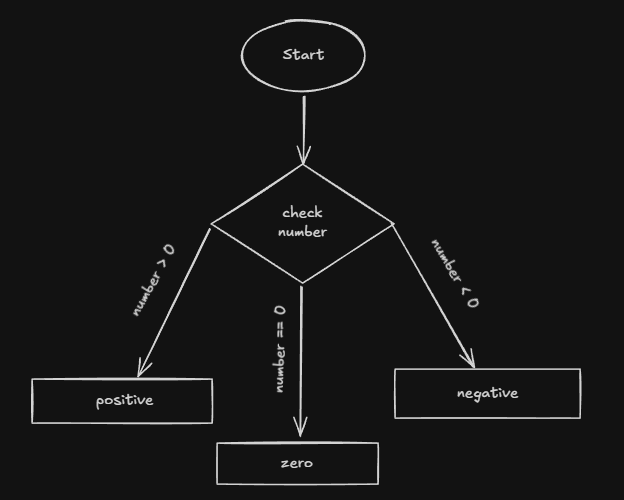

In [20]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [21]:
class AgentState(TypedDict):
    number: int
    final : str

In [22]:
def positive(state: AgentState) -> AgentState:
    """This node checks if the input number is positive."""
    state['final'] = "positive"
    return state

def zero(state: AgentState) -> AgentState:
    """This node checks if the input number is zero."""
    state['final'] = "zero"
    return state

def negative(state: AgentState) -> AgentState:
    """This node checks if the input number is negative."""
    state['final'] = "negative"
    return state

def check(state: AgentState) -> str:
    """This node checks the final state and returns a message."""
    if state['number'] > 0:
        return "positive"
    elif state['number'] == 0:
        return "zero"   
    elif state['number'] < 0:
        return "negative"
    else:
        return "Invalid state."


In [23]:
graph = StateGraph(AgentState)

graph.add_node("pos", positive)
graph.add_node('zer', zero)
graph.add_node('neg', negative)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    check,
    {   
        "positive": "pos",
        "zero": "zer",
        "negative": "neg"
    }
)

app = graph.compile()

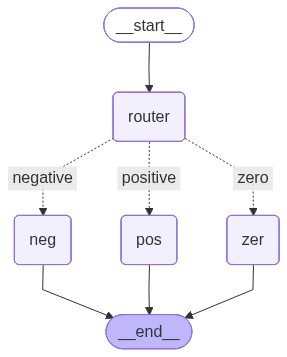

In [24]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [25]:
answer = app.invoke({"number": -5})
print(answer['final'])

negative
